# 3 - Impact of drift and volatility

We now look at how the drift $\mu$ and volatility $\sigma$ in our GBM model for the underlying impact the standard deviation of the PnL of our long LETF/short underlying portfolio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from simulation import simulate_gbm

In [2]:
def std_diff(S0, mu, sigma, T, N, n_paths, leverage):
    return simulate_gbm(S0, mu, sigma, T, int(N), n_paths, leverage).std()

In [3]:
def plot_heat_drift_vol_std(
    mus=np.linspace(-1, 1, 20),
    sigmas=np.linspace(0.01, 0.3, 20),
    T=5,
    freq=1,
    n_paths=1000,
    factor=2,
):
    mu, sigma = np.meshgrid(mus, sigmas)

    diff = np.log(np.vectorize(std_diff)(1, mu, sigma, T, T * freq, n_paths, factor))

    plt.figure(figsize=(4, 3))
    plt.contourf(mu, sigma, diff, cmap="coolwarm")
    plt.title("Standard deviation of percentage difference lETF - underlying")
    plt.xlabel("mu")
    plt.ylabel("sigma")
    plt.colorbar()

Leverage factor 1.1

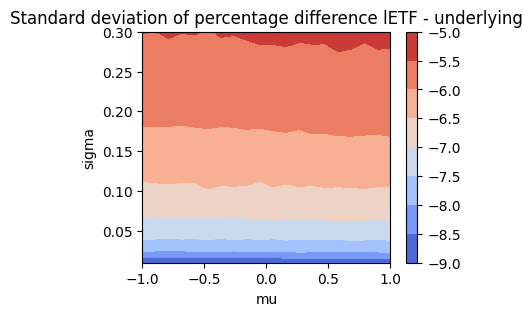

In [4]:
plot_heat_drift_vol_std(factor=1.1)

Leverage factor 1.5

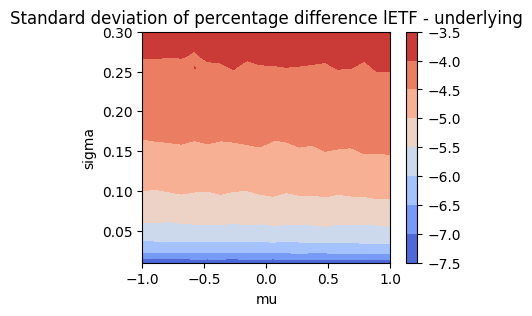

In [5]:
plot_heat_drift_vol_std(factor=1.5)

Leverage factor 2

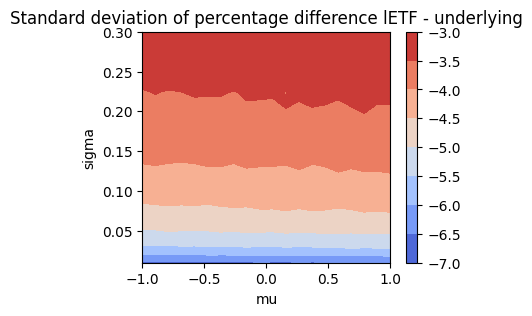

In [6]:
plot_heat_drift_vol_std(factor=2)

Leverage factor 3

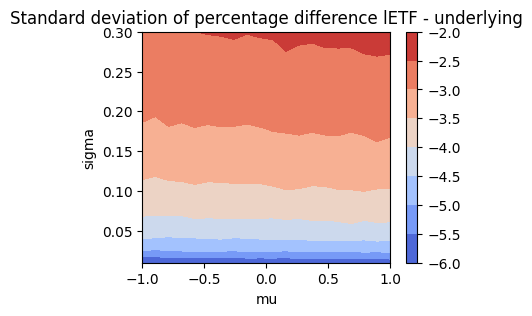

In [7]:
plot_heat_drift_vol_std(factor=3)

Leverage factor 5

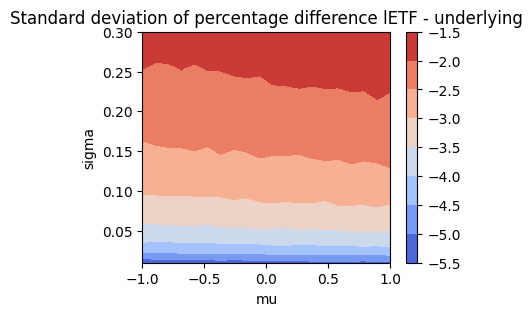

In [8]:
plot_heat_drift_vol_std(factor=5)

There seems to be some influence of $\mu$ and $\sigma$ on the standard deviation, especially for larger leverage factors, but we clearly see that the dependence of the standard deviation is primarily on $\sigma$.